# Baseline Biomarkers and Clinical Outcomes

## Scientific question

Are baseline biomarker levels associated with objective response in TRIDENT-201?

## Initial endpoint

Best Overall Response (BOR) will be categorized as:

- **Responder:** CR or PR
- **Non-responder:** SD or PD

The initial analysis will compare baseline biomarker distributions between these two independent outcome groups.

Because dichotomizing BOR removes clinical detail, the original CR, PR, SD, and PD categories will be retained in the analysis dataset.

In [3]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path.cwd().parent

clinical_path = PROJECT_ROOT / "data" / "raw" / "clinical.csv"
biomarker_path = PROJECT_ROOT / "data" / "raw" / "biomarkers.csv"

clinical_df = pd.read_csv(clinical_path)
biomarker_df = pd.read_csv(biomarker_path)

print("Clinical data shape:", clinical_df.shape)
print("Biomarker data shape:", biomarker_df.shape)

print("\nClinical columns:")
print(clinical_df.columns.tolist())

print("\nBiomarker columns:")
print(biomarker_df.columns.tolist())

Clinical data shape: (251, 15)
Biomarker data shape: (248, 9)

Clinical columns:
['patient_id', 'treatment_arm', 'age', 'sex', 'disease_stage', 'ecog_status', 'smoking_status', 'histology', 'best_overall_response', 'pfs_days', 'pfs_event', 'os_days', 'os_event', 'study_site', 'enrollment_date']

Biomarker columns:
['patient_id', 'sample_timepoint', 'il6_pg_ml', 'crp_mg_l', 'tnf_alpha_pg_ml', 'ifn_gamma_pg_ml', 'vegf_pg_ml', 'pdl1_tps_percent', 'ctdna_fraction_percent']


## Objective-response endpoint

Best Overall Response (BOR) was dichotomized for the initial analysis:

- Responder: CR or PR
- Non-responder: SD or PD

The original BOR variable was retained to preserve the four-category clinical outcome.
Previously identified duplicate patient records were removed before analysis.

In [5]:
# Apply the previously established deduplication
clinical_clean = (
    clinical_df
    .drop_duplicates(subset="patient_id", keep="first")
    .copy()
)

baseline_biomarkers = (
    biomarker_df
    .loc[biomarker_df["sample_timepoint"] == "Baseline"]
    .drop_duplicates(subset="patient_id", keep="first")
    .copy()
)

# Create a binary response variable without changing the original BOR column
response_map = {
    "CR": "Responder",
    "PR": "Responder",
    "SD": "Non-responder",
    "PD": "Non-responder",
}

clinical_clean["response_group"] = (
    clinical_clean["best_overall_response"].map(response_map)
)

print("Original BOR categories:")
print(
    clinical_clean["best_overall_response"]
    .value_counts(dropna=False)
)

print("\nBinary response groups:")
print(
    clinical_clean["response_group"]
    .value_counts(dropna=False)
)

print("\nUnique clinical patients:", clinical_clean["patient_id"].nunique())
print("Unique baseline biomarker patients:", baseline_biomarkers["patient_id"].nunique())

Original BOR categories:
best_overall_response
PD     91
SD     90
PR     63
CR      5
NaN     1
Name: count, dtype: int64

Binary response groups:
response_group
Non-responder    181
Responder         68
NaN                1
Name: count, dtype: int64

Unique clinical patients: 250
Unique baseline biomarker patients: 247


In [6]:
# Retain patients with an evaluable objective-response outcome
response_evaluable = clinical_clean.loc[
    clinical_clean["response_group"].notna()
].copy()

# Merge clinical outcomes with baseline biomarkers
response_analysis = response_evaluable.merge(
    baseline_biomarkers,
    on="patient_id",
    how="inner",
    validate="one_to_one"
)

print("Response-evaluable clinical patients:", len(response_evaluable))
print("Patients in merged analysis:", len(response_analysis))

print("\nResponse groups in merged dataset:")
print(response_analysis["response_group"].value_counts())

print("\nMissing values in IL-6 and ctDNA:")
print(
    response_analysis[
        ["il6_pg_ml", "ctdna_fraction_percent"]
    ].isna().sum()
)

Response-evaluable clinical patients: 249
Patients in merged analysis: 246

Response groups in merged dataset:
response_group
Non-responder    179
Responder         67
Name: count, dtype: int64

Missing values in IL-6 and ctDNA:
il6_pg_ml                 1
ctdna_fraction_percent    0
dtype: int64


In [7]:
biomarkers_of_interest = [
    "il6_pg_ml",
    "ctdna_fraction_percent",
]

sample_sizes = (
    response_analysis
    .groupby("response_group")[biomarkers_of_interest]
    .count()
    .rename_axis("response_group")
)

print(sample_sizes)

                il6_pg_ml  ctdna_fraction_percent
response_group                                   
Non-responder         178                     179
Responder              67                      67


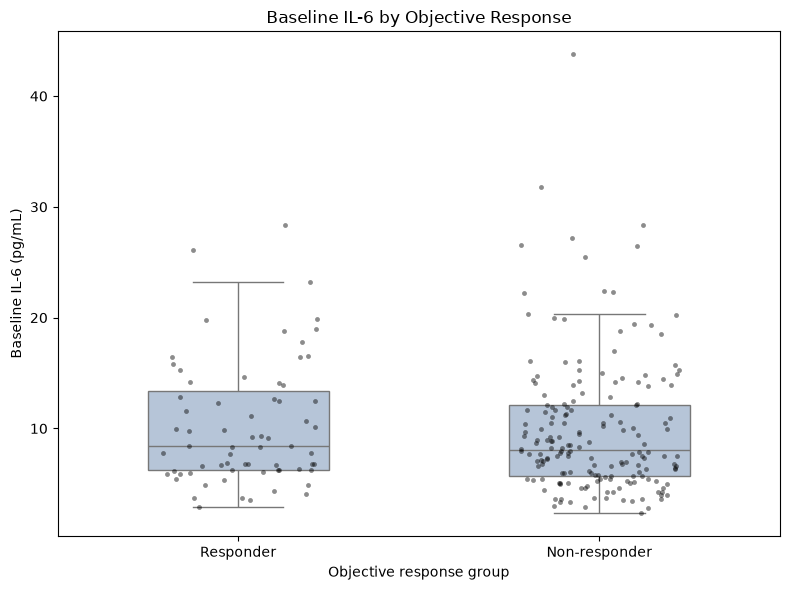

In [8]:
response_order = ["Responder", "Non-responder"]

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=response_analysis,
    x="response_group",
    y="il6_pg_ml",
    order=response_order,
    showfliers=False,
    width=0.5,
    color="lightsteelblue",
)

sns.stripplot(
    data=response_analysis,
    x="response_group",
    y="il6_pg_ml",
    order=response_order,
    color="black",
    alpha=0.45,
    jitter=0.22,
    size=3.5,
)

plt.xlabel("Objective response group")
plt.ylabel("Baseline IL-6 (pg/mL)")
plt.title("Baseline IL-6 by Objective Response")
plt.tight_layout()
plt.show()

In [9]:
il6_summary = (
    response_analysis
    .groupby("response_group")["il6_pg_ml"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
    .reindex(response_order)
)

il6_summary["iqr"] = il6_summary["q3"] - il6_summary["q1"]

print(il6_summary.round(2))

                  n   mean  median   std    q1     q3   iqr
response_group                                             
Responder        67  10.28    8.39  5.60  6.22  13.40  7.18
Non-responder   178   9.94    8.06  6.15  5.71  12.16  6.45


In [10]:
# Compare baseline IL-6 distributions between responders and non-responders

# Extract non-missing IL-6 values for responders
il6_responders = response_analysis.loc[
    response_analysis["response_group"] == "Responder",
    "il6_pg_ml",
].dropna()

# Extract non-missing IL-6 values for non-responders
il6_nonresponders = response_analysis.loc[
    response_analysis["response_group"] == "Non-responder",
    "il6_pg_ml",
].dropna()

# Perform a two-sided Mann–Whitney U test
u_statistic, p_value = stats.mannwhitneyu(
    il6_responders,
    il6_nonresponders,
    alternative="two-sided",
)

# Display the statistical results
print(f"Mann–Whitney U statistic: {u_statistic:.1f}")
print(f"Two-sided p-value: {p_value:.4f}")

Mann–Whitney U statistic: 6329.0
Two-sided p-value: 0.4598


In [11]:
# Convert the Mann–Whitney U statistic into an interpretable effect size

# Count the number of patients in each response group
n_responders = len(il6_responders)
n_nonresponders = len(il6_nonresponders)

# Calculate all possible responder–non-responder patient pairs
n_pairs = n_responders * n_nonresponders

# Estimate the probability that a responder has higher IL-6
probability_superiority = u_statistic / n_pairs

# Convert the probability into a rank-biserial correlation
rank_biserial = (2 * probability_superiority) - 1

# Display the results
print(f"Number of patient pairs: {n_pairs:,}")
print(
    "Probability that a responder has higher IL-6: "
    f"{probability_superiority:.3f}"
)
print(f"Rank-biserial correlation: {rank_biserial:.3f}")

Number of patient pairs: 11,926
Probability that a responder has higher IL-6: 0.531
Rank-biserial correlation: 0.061


In [12]:
# Estimate a 95% confidence interval for the IL-6 effect size using bootstrap resampling

# Create a reproducible random-number generator
rng = np.random.default_rng(seed=42)

# Convert the two groups to NumPy arrays
responder_values = il6_responders.to_numpy()
nonresponder_values = il6_nonresponders.to_numpy()

# Set the number of bootstrap samples
n_bootstrap = 5000
bootstrap_effects = np.empty(n_bootstrap)

# Repeatedly resample patients within each response group
for i in range(n_bootstrap):
    responder_sample = rng.choice(
        responder_values,
        size=len(responder_values),
        replace=True,
    )
    
    nonresponder_sample = rng.choice(
        nonresponder_values,
        size=len(nonresponder_values),
        replace=True,
    )

    # Calculate the Mann–Whitney effect size for this bootstrap sample
    bootstrap_u = stats.mannwhitneyu(
        responder_sample,
        nonresponder_sample,
        alternative="two-sided",
    ).statistic

    bootstrap_probability = bootstrap_u / (
        len(responder_sample) * len(nonresponder_sample)
    )

    bootstrap_effects[i] = (2 * bootstrap_probability) - 1

# Use the middle 95% of bootstrap estimates as the confidence interval
ci_lower, ci_upper = np.percentile(
    bootstrap_effects,
    [2.5, 97.5],
)

# Display the observed effect size and its uncertainty
print(f"Rank-biserial correlation: {rank_biserial:.3f}")
print(f"Bootstrap 95% CI: {ci_lower:.3f} to {ci_upper:.3f}")

Rank-biserial correlation: 0.061
Bootstrap 95% CI: -0.098 to 0.224


### IL-6 interpretation

Baseline IL-6 showed minimal separation between objective responders and
non-responders. Responders had a median IL-6 of 8.39 pg/mL, compared with
8.06 pg/mL among non-responders, corresponding to an observed median
difference of 0.33 pg/mL.

The probability that a randomly selected responder had higher baseline IL-6
than a randomly selected non-responder was 53.1% (rank-biserial correlation =
0.061; bootstrap 95% CI: -0.098 to 0.224). The confidence interval included
zero, and the two-sided Mann-Whitney U test did not provide clear evidence of
a distributional difference (U = 6329, raw p = 0.460).

Overall, baseline IL-6 demonstrated limited potential as a standalone
objective-response biomarker in this exploratory dataset. This finding does
not exclude a possible role for IL-6 in combination with other biomarkers or
clinical variables.

### Baseline ctDNA and objective response

**Objective:** Evaluate whether baseline ctDNA fraction differs between
objective responders (CR/PR) and non-responders (SD/PD).

**Biological hypothesis:** Higher baseline ctDNA may reflect greater tumor
burden or more aggressive disease and may therefore be associated with
non-response.

The analysis will first examine patient-level distributions and descriptive
statistics before estimating the effect size, uncertainty, and statistical
evidence.

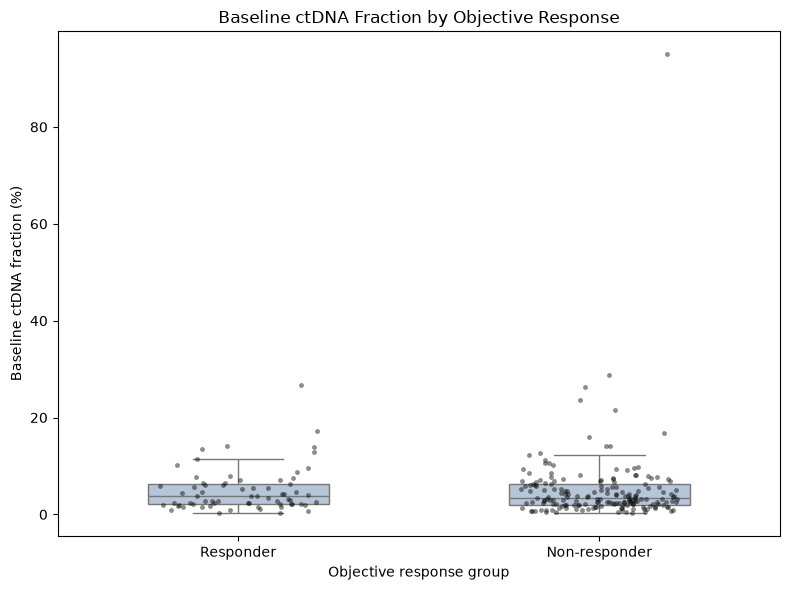

In [13]:
# Visualize baseline ctDNA distributions by objective-response group

plt.figure(figsize=(8, 6))

# Display the median and interquartile range for each group
sns.boxplot(
    data=response_analysis,
    x="response_group",
    y="ctdna_fraction_percent",
    order=response_order,
    showfliers=False,
    width=0.5,
    color="lightsteelblue",
)

# Overlay all individual patient measurements
sns.stripplot(
    data=response_analysis,
    x="response_group",
    y="ctdna_fraction_percent",
    order=response_order,
    color="black",
    alpha=0.45,
    jitter=0.22,
    size=3.5,
)

# Add clear scientific labels
plt.xlabel("Objective response group")
plt.ylabel("Baseline ctDNA fraction (%)")
plt.title("Baseline ctDNA Fraction by Objective Response")
plt.tight_layout()
plt.show()

### Baseline ctDNA and objective response

**Objective:** Evaluate whether baseline ctDNA fraction differs between
objective responders (CR/PR) and non-responders (SD/PD).

**Biological hypothesis:** Higher baseline ctDNA may reflect greater tumor
burden or more aggressive disease and may therefore be associated with
non-response.

The analysis will first examine patient-level distributions and descriptive
statistics before estimating the effect size, uncertainty, and statistical
evidence.

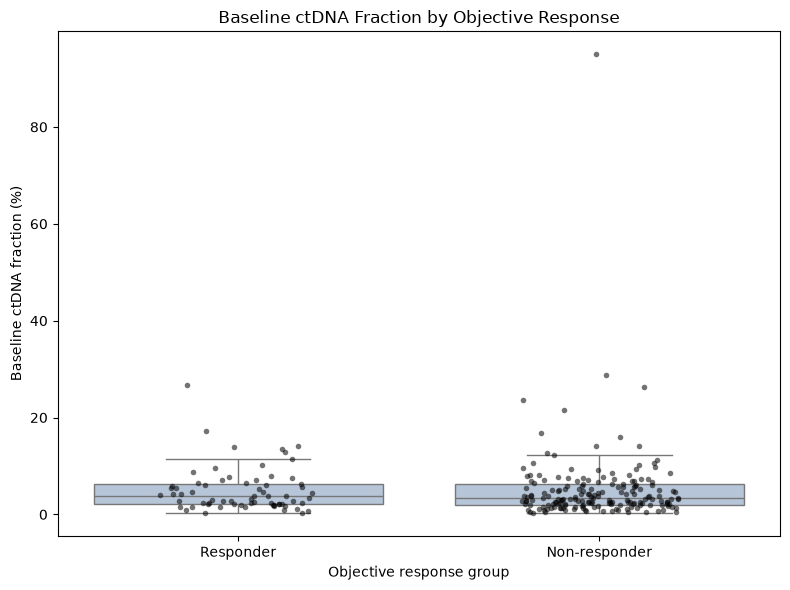

In [14]:
# Set the response groups in the order we want them displayed
response_order = ["Responder", "Non-responder"]

# Create the figure
plt.figure(figsize=(8, 6))

# Show the ctDNA distribution and group medians/interquartile ranges
sns.boxplot(
    data=response_analysis,
    x="response_group",
    y="ctdna_fraction_percent",
    order=response_order,
    showfliers=False,
    color="lightsteelblue"
)

# Overlay every patient's ctDNA value
sns.stripplot(
    data=response_analysis,
    x="response_group",
    y="ctdna_fraction_percent",
    order=response_order,
    color="black",
    alpha=0.55,
    jitter=0.22,
    size=4
)

# Add clear labels and a descriptive title
plt.xlabel("Objective response group")
plt.ylabel("Baseline ctDNA fraction (%)")
plt.title("Baseline ctDNA Fraction by Objective Response")

# Improve spacing
plt.tight_layout()

# Display the figure without saving it yet
plt.show()

#### Inspection of extreme ctDNA values

**Objective:** Identify the patients with the highest baseline ctDNA fractions
and determine whether an extreme value is compressing the visualization of the
typical responder and non-responder distributions.

This inspection does not assume that an extreme value is erroneous or justify
its removal. It provides patient-level context before choosing an appropriate
visualization or conducting sensitivity analysis.

In [15]:
# Display the 10 highest baseline ctDNA values
# Include patient ID and response group to provide clinical context
response_analysis[
    ["patient_id", "response_group", "ctdna_fraction_percent"]
].sort_values(
    by="ctdna_fraction_percent",
    ascending=False
).head(10)

,patient_id,response_group,ctdna_fraction_percent
17,TRI-018,Non-responder,95.00
231,TRI-233,Non-responder,28.87
56,TRI-057,Responder,26.73
196,TRI-198,Non-responder,26.28
156,TRI-158,Non-responder,23.53
67,TRI-068,Non-responder,21.55
48,TRI-049,Responder,17.25
64,TRI-065,Non-responder,16.73
35,TRI-036,Non-responder,15.93
89,TRI-090,Non-responder,14.20


#### Zoomed visualization of baseline ctDNA

**Objective:** Compare the typical responder and non-responder ctDNA
distributions more clearly by limiting the displayed y-axis while retaining
all patients in the analysis.

TRI-018 has an unusually high baseline ctDNA fraction of 95%, compared with
the next-highest observed value of 28.87%. The zoomed axis improves visual
comparison but does not remove or exclude this patient from subsequent
statistical analyses.

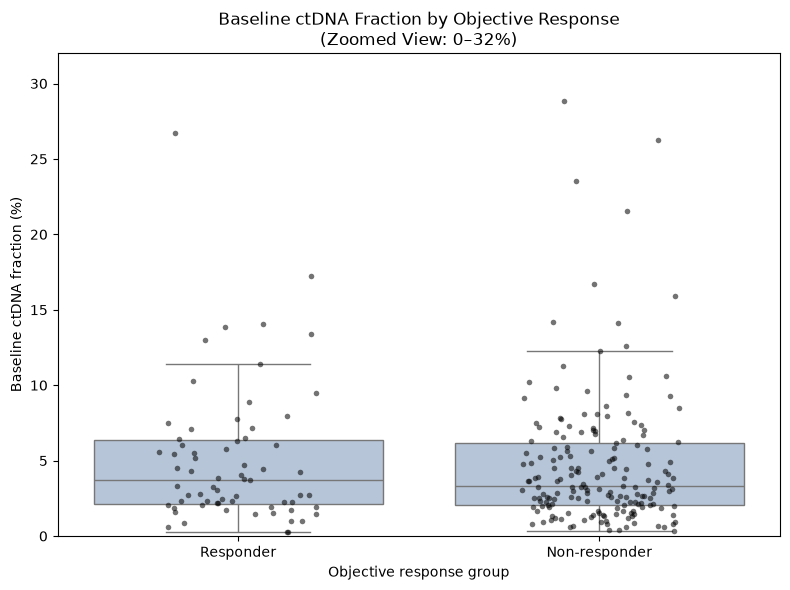

In [16]:
# Create a second plot focused on the range containing most observations
plt.figure(figsize=(8, 6))

# Display the boxplots without separately drawing boxplot outlier markers
sns.boxplot(
    data=response_analysis,
    x="response_group",
    y="ctdna_fraction_percent",
    order=["Responder", "Non-responder"],
    showfliers=False,
    color="lightsteelblue"
)

# Overlay individual patient observations
sns.stripplot(
    data=response_analysis,
    x="response_group",
    y="ctdna_fraction_percent",
    order=["Responder", "Non-responder"],
    color="black",
    alpha=0.55,
    jitter=0.22,
    size=4
)

# Zoom the displayed axis to make the typical distributions easier to compare
# This changes only the view; it does not remove patients from the dataset
plt.ylim(0, 32)

# Add clear labels and title
plt.xlabel("Objective response group")
plt.ylabel("Baseline ctDNA fraction (%)")
plt.title("Baseline ctDNA Fraction by Objective Response\n(Zoomed View: 0–32%)")

# Improve spacing and display the figure
plt.tight_layout()
plt.show()

#### Descriptive statistics for baseline ctDNA

**Objective:** Quantify the center and spread of baseline ctDNA within each
response group before conducting statistical inference.

The comparison will prioritize the median and interquartile range because the
ctDNA distribution contains an extreme value. The mean and standard deviation
will also be reported to show how sensitive these measures are to that value.

In [17]:
# Calculate descriptive statistics for ctDNA within each response group
ctdna_summary = (
    response_analysis
    .groupby("response_group")["ctdna_fraction_percent"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
)

# Calculate the interquartile range
ctdna_summary["iqr"] = ctdna_summary["q3"] - ctdna_summary["q1"]

# Arrange the groups and round values for easier interpretation
ctdna_summary = ctdna_summary.loc[
    ["Responder", "Non-responder"]
].round(2)

ctdna_summary

,n,mean,median,std,q1,q3,iqr
response_group,,,,,,,
Responder,67,5.04,3.70,4.59,2.12,6.36,4.23
Non-responder,179,5.22,3.29,8.06,2.04,6.20,4.15


#### Mann–Whitney U test for baseline ctDNA

**Objective:** Evaluate whether baseline ctDNA values generally tend to be
higher in one objective-response group than in the other.

A two-sided Mann–Whitney U test is used because ctDNA is right-skewed and
contains an extreme observation. The test compares the relative ranks of the
two distributions rather than their means. It does not test prediction
accuracy, establish causation, or directly test the numerical difference
between medians.

In [18]:
from scipy.stats import mannwhitneyu

# Extract non-missing ctDNA values for each response group
ctdna_responders = response_analysis.loc[
    response_analysis["response_group"] == "Responder",
    "ctdna_fraction_percent"
].dropna()

ctdna_nonresponders = response_analysis.loc[
    response_analysis["response_group"] == "Non-responder",
    "ctdna_fraction_percent"
].dropna()

# Perform a two-sided Mann–Whitney U test
# Responders are entered first, so U describes responder-versus-non-responder ranks
ctdna_u_statistic, ctdna_p_value = mannwhitneyu(
    ctdna_responders,
    ctdna_nonresponders,
    alternative="two-sided"
)

# Display the group sample sizes and test results
print(f"Responders: n = {len(ctdna_responders)}")
print(f"Non-responders: n = {len(ctdna_nonresponders)}")
print(f"Mann–Whitney U statistic: {ctdna_u_statistic:.1f}")
print(f"Two-sided raw p-value: {ctdna_p_value:.4f}")

Responders: n = 67
Non-responders: n = 179
Mann–Whitney U statistic: 6173.5
Two-sided raw p-value: 0.7224


#### Probability of superiority and rank-biserial correlation

**Objective:** Quantify the direction and magnitude of ctDNA separation
between responders and non-responders.

Probability of superiority estimates how often a randomly selected responder
has a higher baseline ctDNA value than a randomly selected non-responder.
Rank-biserial correlation expresses the same comparison on a scale from
−1 to +1, where zero indicates little group separation.

In [19]:
# Calculate the total number of responder–non-responder patient pairs
ctdna_total_pairs = len(ctdna_responders) * len(ctdna_nonresponders)

# Because responders were entered first in the Mann–Whitney test,
# U divided by all possible pairs estimates the probability that
# a randomly selected responder has higher ctDNA than a non-responder
ctdna_probability_superiority = ctdna_u_statistic / ctdna_total_pairs

# Convert probability of superiority to rank-biserial correlation
# Positive values indicate a tendency toward higher ctDNA in responders
ctdna_rank_biserial = (2 * ctdna_probability_superiority) - 1

# Display the effect-size results
print(f"Total responder–non-responder pairs: {ctdna_total_pairs:,}")
print(
    "Probability that a responder has higher ctDNA: "
    f"{ctdna_probability_superiority:.3f}"
)
print(f"Rank-biserial correlation: {ctdna_rank_biserial:.3f}")

Total responder–non-responder pairs: 11,993
Probability that a responder has higher ctDNA: 0.515
Rank-biserial correlation: 0.030


#### Bootstrap confidence interval for the ctDNA effect size

**Objective:** Estimate the sampling uncertainty around the rank-biserial
correlation between baseline ctDNA and objective response.

Patients will be resampled with replacement within each response group.
The rank-biserial correlation will be recalculated 5,000 times, and the
2.5th and 97.5th percentiles will define the bootstrap 95% confidence
interval.

In [20]:
# Create a reproducible random-number generator
rng = np.random.default_rng(seed=42)

# Store the bootstrapped rank-biserial correlations
ctdna_bootstrap_effects = []

# Repeat the resampling procedure 5,000 times
for _ in range(5000):

    # Resample patients within each response group with replacement
    responder_sample = rng.choice(
        ctdna_responders,
        size=len(ctdna_responders),
        replace=True
    )
    nonresponder_sample = rng.choice(
        ctdna_nonresponders,
        size=len(ctdna_nonresponders),
        replace=True
    )

    # Recalculate the Mann–Whitney U statistic for the resampled groups
    bootstrap_u, _ = mannwhitneyu(
        responder_sample,
        nonresponder_sample,
        alternative="two-sided"
    )

    # Convert U to a rank-biserial correlation
    bootstrap_probability = bootstrap_u / (
        len(responder_sample) * len(nonresponder_sample)
    )
    bootstrap_rank_biserial = (2 * bootstrap_probability) - 1

    ctdna_bootstrap_effects.append(bootstrap_rank_biserial)

# Calculate the percentile-based 95% confidence interval
ctdna_ci_lower, ctdna_ci_upper = np.percentile(
    ctdna_bootstrap_effects,
    [2.5, 97.5]
)

# Display the observed effect size and its uncertainty
print(f"Rank-biserial correlation: {ctdna_rank_biserial:.3f}")
print(
    f"Bootstrap 95% CI: {ctdna_ci_lower:.3f} to "
    f"{ctdna_ci_upper:.3f}"
)

Rank-biserial correlation: 0.030
Bootstrap 95% CI: -0.133 to 0.191


### ctDNA interpretation

Baseline ctDNA showed minimal separation between objective responders and
non-responders. Responders had a median ctDNA fraction of 3.70%, compared
with 3.29% among non-responders, corresponding to an observed median
difference of 0.41 percentage points. The groups had similar interquartile
ranges and substantial distributional overlap.

The probability that a randomly selected responder had a higher baseline
ctDNA fraction than a randomly selected non-responder was 51.5%
(rank-biserial correlation = 0.030; bootstrap 95% CI: −0.133 to 0.191).
The confidence interval included zero, indicating uncertainty about the
direction of the association. The two-sided Mann–Whitney U test provided
no clear statistical evidence of a distributional difference
(U = 6173.5, raw p = 0.722).

One non-responder had an unusually high ctDNA fraction of 95%, compared
with the next-highest value of 28.87%. This observation increased the
non-responder mean and standard deviation but had limited influence on the
rank-based analysis. It was retained because an extreme value should not
be excluded without evidence of a measurement or data-entry error.

Overall, baseline ctDNA demonstrated limited potential as a standalone
objective-response biomarker in this exploratory dataset. This finding
does not exclude a possible role for ctDNA in combination with clinical
variables, other biomarkers, or longitudinal ctDNA measurements.

#### Sensitivity analysis for the extreme ctDNA observation

**Objective:** Determine whether the unusually high ctDNA value for TRI-018
materially changes the estimated responder–non-responder difference.

The primary analysis retains TRI-018. This sensitivity analysis temporarily
excludes the observation only to assess its influence; exclusion is not being
treated as a data-cleaning correction.

In [21]:
# Temporarily exclude TRI-018 for sensitivity analysis only
ctdna_sensitivity = response_analysis.loc[
    response_analysis["patient_id"] != "TRI-018"
].copy()

# Extract non-missing ctDNA values from each response group
ctdna_resp_sensitivity = ctdna_sensitivity.loc[
    ctdna_sensitivity["response_group"] == "Responder",
    "ctdna_fraction_percent"
].dropna()

ctdna_nonresp_sensitivity = ctdna_sensitivity.loc[
    ctdna_sensitivity["response_group"] == "Non-responder",
    "ctdna_fraction_percent"
].dropna()

# Repeat the two-sided Mann–Whitney U test
sensitivity_u, sensitivity_p = mannwhitneyu(
    ctdna_resp_sensitivity,
    ctdna_nonresp_sensitivity,
    alternative="two-sided"
)

# Convert U into probability of superiority and rank-biserial correlation
sensitivity_pairs = (
    len(ctdna_resp_sensitivity) * len(ctdna_nonresp_sensitivity)
)
sensitivity_probability = sensitivity_u / sensitivity_pairs
sensitivity_rank_biserial = (2 * sensitivity_probability) - 1

# Compare the primary and sensitivity-analysis results
print("Primary analysis including TRI-018")
print(f"Rank-biserial correlation: {ctdna_rank_biserial:.3f}")
print(f"Raw p-value: {ctdna_p_value:.4f}")

print("\nSensitivity analysis excluding TRI-018")
print(f"Responders: n = {len(ctdna_resp_sensitivity)}")
print(f"Non-responders: n = {len(ctdna_nonresp_sensitivity)}")
print(f"Rank-biserial correlation: {sensitivity_rank_biserial:.3f}")
print(f"Raw p-value: {sensitivity_p:.4f}")

Primary analysis including TRI-018
Rank-biserial correlation: 0.030
Raw p-value: 0.7224

Sensitivity analysis excluding TRI-018
Responders: n = 67
Non-responders: n = 178
Rank-biserial correlation: 0.035
Raw p-value: 0.6710


#### ctDNA sensitivity-analysis interpretation

Excluding the extreme ctDNA observation for TRI-018 produced little change
in the estimated group separation. The rank-biserial correlation changed
from 0.030 in the primary analysis to 0.035 in the sensitivity analysis,
while the raw p-value changed from 0.722 to 0.671.

Therefore, the conclusion that baseline ctDNA showed minimal separation
between responders and non-responders was not driven by TRI-018. The primary
analysis retains this patient because there is no evidence that the value
resulted from a measurement or data-entry error.

### Baseline IFN-γ and objective response

**Objective:** Evaluate whether baseline IFN-γ differs between objective
responders (CR/PR) and non-responders (SD/PD).

**Biological hypothesis:** Higher baseline IFN-γ may reflect greater T-cell
and NK-cell activity and a more immune-active tumor environment and may
therefore be associated with objective response.

IFN-γ can also induce compensatory immune-evasion mechanisms, including
PD-L1 expression. Therefore, higher baseline IFN-γ does not necessarily
indicate an effective antitumor response.

The analysis will first examine patient-level distributions before
quantifying the effect size, uncertainty, and statistical evidence.

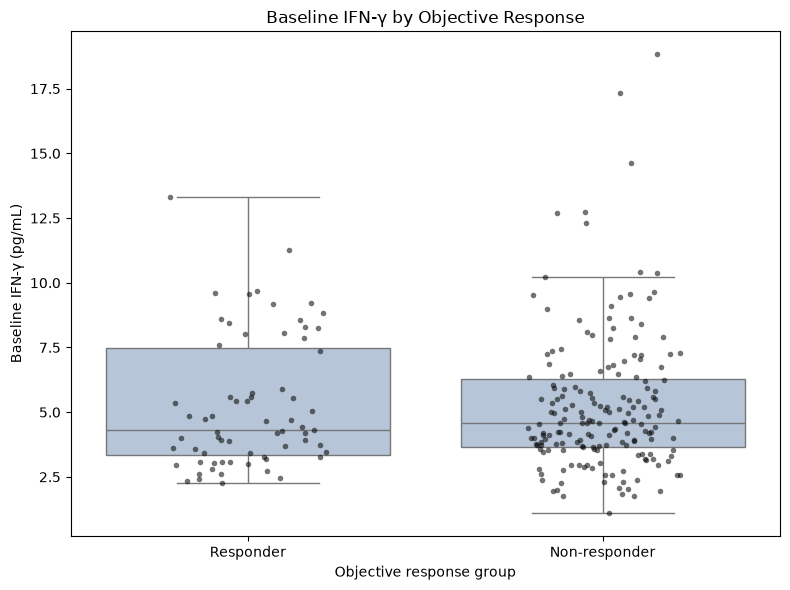

In [22]:
# Set the response-group display order
response_order = ["Responder", "Non-responder"]

# Create the figure
plt.figure(figsize=(8, 6))

# Display the IFN-γ distribution, median, and interquartile range
sns.boxplot(
    data=response_analysis,
    x="response_group",
    y="ifn_gamma_pg_ml",
    order=response_order,
    showfliers=False,
    color="lightsteelblue"
)

# Overlay individual patient measurements
sns.stripplot(
    data=response_analysis,
    x="response_group",
    y="ifn_gamma_pg_ml",
    order=response_order,
    color="black",
    alpha=0.55,
    jitter=0.22,
    size=4
)

# Add clear labels and a descriptive title
plt.xlabel("Objective response group")
plt.ylabel("Baseline IFN-γ (pg/mL)")
plt.title("Baseline IFN-γ by Objective Response")

# Improve spacing and display the figure
plt.tight_layout()
plt.show()

#### Descriptive statistics for baseline IFN-γ

**Objective:** Quantify the center and spread of baseline IFN-γ within each
response group and determine whether the greater visual variability among
responders is reflected in the numerical summaries.

The median and interquartile range will describe the typical distribution,
while the mean and standard deviation will provide additional information
about asymmetry and extreme observations.

In [23]:
# Calculate descriptive statistics for IFN-γ within each response group
ifng_summary = (
    response_analysis
    .groupby("response_group")["ifn_gamma_pg_ml"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
)

# Calculate the interquartile range
ifng_summary["iqr"] = ifng_summary["q3"] - ifng_summary["q1"]

# Arrange the response groups and round values for interpretation
ifng_summary = ifng_summary.loc[
    ["Responder", "Non-responder"]
].round(2)

ifng_summary

,n,mean,median,std,q1,q3,iqr
response_group,,,,,,,
Responder,67,5.28,4.3,2.53,3.34,7.48,4.14
Non-responder,179,5.26,4.6,2.69,3.66,6.30,2.64


#### Mann–Whitney U test for baseline IFN-γ

**Objective:** Evaluate whether baseline IFN-γ values generally tend to be
higher in one objective-response group than in the other.

The Mann–Whitney U test compares the relative ranks of the two distributions.
Because the groups appear to differ somewhat in spread, the test should be
interpreted as a comparison of overall distributions rather than strictly as
a test of medians.

In [24]:
# Extract non-missing IFN-γ measurements for each response group
ifng_responders = response_analysis.loc[
    response_analysis["response_group"] == "Responder",
    "ifn_gamma_pg_ml"
].dropna()

ifng_nonresponders = response_analysis.loc[
    response_analysis["response_group"] == "Non-responder",
    "ifn_gamma_pg_ml"
].dropna()

# Perform a two-sided Mann–Whitney U test
# Responders are entered first, preserving our effect-size direction
ifng_u_statistic, ifng_p_value = mannwhitneyu(
    ifng_responders,
    ifng_nonresponders,
    alternative="two-sided"
)

# Display sample sizes and test results
print(f"Responders: n = {len(ifng_responders)}")
print(f"Non-responders: n = {len(ifng_nonresponders)}")
print(f"Mann–Whitney U statistic: {ifng_u_statistic:.1f}")
print(f"Two-sided raw p-value: {ifng_p_value:.4f}")

Responders: n = 67
Non-responders: n = 179
Mann–Whitney U statistic: 5928.0
Two-sided raw p-value: 0.8911


#### Probability of superiority and rank-biserial correlation

**Objective:** Quantify the direction and magnitude of baseline IFN-γ
separation between responders and non-responders.

Probability of superiority estimates how often a randomly selected responder
has a higher IFN-γ value than a randomly selected non-responder.
Rank-biserial correlation expresses this comparison on a scale from −1 to
+1. Positive values favor higher IFN-γ among responders, while negative
values favor higher IFN-γ among non-responders.

In [25]:
# Calculate the number of possible responder–non-responder pairs
ifng_total_pairs = len(ifng_responders) * len(ifng_nonresponders)

# Convert the Mann–Whitney U statistic into probability of superiority
# Responders were entered first in the Mann–Whitney test
ifng_probability_superiority = ifng_u_statistic / ifng_total_pairs

# Convert probability of superiority to rank-biserial correlation
# Positive values indicate a tendency toward higher IFN-γ in responders
ifng_rank_biserial = (2 * ifng_probability_superiority) - 1

# Display the effect-size results
print(f"Total responder–non-responder pairs: {ifng_total_pairs:,}")
print(
    "Probability that a responder has higher IFN-γ: "
    f"{ifng_probability_superiority:.3f}"
)
print(f"Rank-biserial correlation: {ifng_rank_biserial:.3f}")

Total responder–non-responder pairs: 11,993
Probability that a responder has higher IFN-γ: 0.494
Rank-biserial correlation: -0.011


#### Bootstrap confidence interval for the IFN-γ effect size

**Objective:** Estimate the sampling uncertainty around the rank-biserial
correlation between baseline IFN-γ and objective response.

Patients will be resampled with replacement within each response group.
The rank-biserial correlation will be recalculated 5,000 times, and the
2.5th and 97.5th percentiles will define the bootstrap 95% confidence
interval.

In [26]:
# Create a reproducible random-number generator
rng = np.random.default_rng(seed=42)

# Store the bootstrapped IFN-γ effect sizes
ifng_bootstrap_effects = []

# Repeat the group-wise resampling procedure 5,000 times
for _ in range(5000):

    # Resample patients within each response group with replacement
    responder_sample = rng.choice(
        ifng_responders,
        size=len(ifng_responders),
        replace=True
    )
    nonresponder_sample = rng.choice(
        ifng_nonresponders,
        size=len(ifng_nonresponders),
        replace=True
    )

    # Recalculate the Mann–Whitney U statistic
    bootstrap_u, _ = mannwhitneyu(
        responder_sample,
        nonresponder_sample,
        alternative="two-sided"
    )

    # Convert U into a rank-biserial correlation
    bootstrap_probability = bootstrap_u / (
        len(responder_sample) * len(nonresponder_sample)
    )
    bootstrap_rank_biserial = (2 * bootstrap_probability) - 1

    # Save this bootstrap effect-size estimate
    ifng_bootstrap_effects.append(bootstrap_rank_biserial)

# Calculate the percentile-based 95% confidence interval
ifng_ci_lower, ifng_ci_upper = np.percentile(
    ifng_bootstrap_effects,
    [2.5, 97.5]
)

# Display the observed effect size and confidence interval
print(f"Rank-biserial correlation: {ifng_rank_biserial:.3f}")
print(
    f"Bootstrap 95% CI: {ifng_ci_lower:.3f} to "
    f"{ifng_ci_upper:.3f}"
)

Rank-biserial correlation: -0.011
Bootstrap 95% CI: -0.181 to 0.161


### IFN-γ interpretation

Baseline IFN-γ showed negligible separation between objective responders and
non-responders. Responders had a median IFN-γ concentration of 4.30 pg/mL,
compared with 4.60 pg/mL among non-responders, corresponding to an observed
median difference of −0.30 pg/mL. Mean concentrations were nearly identical
(5.28 versus 5.26 pg/mL).

The middle 50% of responder measurements showed greater variability
(IQR = 4.14 pg/mL) than the non-responder measurements
(IQR = 2.64 pg/mL). However, there was substantial overlap between the
groups.

The probability that a randomly selected responder had higher baseline
IFN-γ than a randomly selected non-responder was 49.4%
(rank-biserial correlation = −0.011; bootstrap 95% CI: −0.181 to 0.161).
The confidence interval included zero and allowed for effects in either
direction. The two-sided Mann–Whitney U test provided no clear statistical
evidence of a distributional difference (U = 5928.0, raw p = 0.891).

Overall, baseline circulating IFN-γ demonstrated limited potential as a
standalone objective-response biomarker in this exploratory dataset. This
finding does not establish that IFN-γ biology is unimportant. A single
circulating baseline measurement may not capture tumor-localized immune
activity, and associations could depend on immune-cell infiltration,
PD-L1 expression, treatment context, or longitudinal changes.

### Baseline PD-L1 TPS and objective response

**Objective:** Evaluate whether baseline PD-L1 Tumor Proportion Score differs
between objective responders (CR/PR) and non-responders (SD/PD).

**Biological hypothesis:** Higher baseline PD-L1 TPS may reflect an
IFN-γ-stimulated, immune-active tumor environment and may therefore be
associated with objective response. However, PD-L1 also mediates immune
evasion, and its association with response may depend on treatment context
and other features of the tumor microenvironment.

PD-L1 TPS represents the percentage of viable tumor cells with membranous
PD-L1 staining. It does not measure PD-L1 expression on immune cells or
directly quantify antitumor T-cell activity.

The analysis will first examine patient-level distributions before
quantifying the effect size, uncertainty, and statistical evidence.

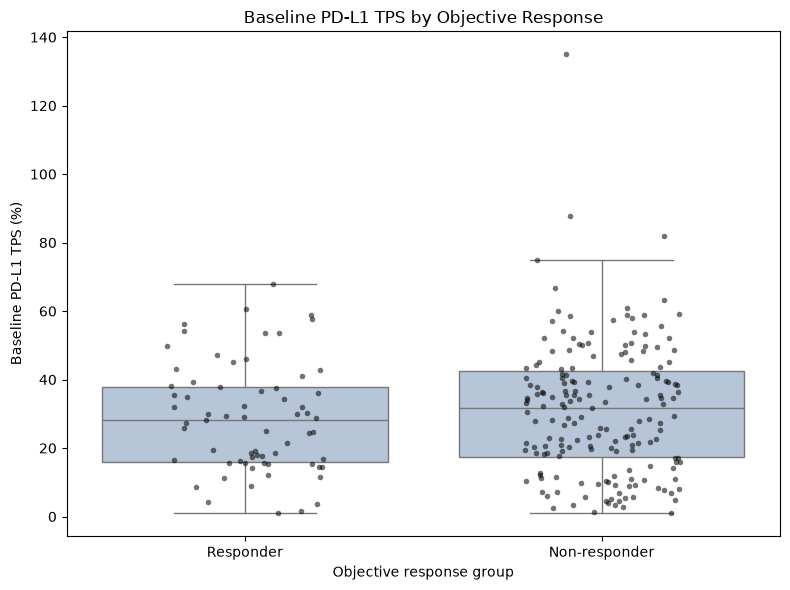

In [27]:
# Set the response-group display order
response_order = ["Responder", "Non-responder"]

# Create the figure
plt.figure(figsize=(8, 6))

# Display the PD-L1 TPS distribution, median, and interquartile range
sns.boxplot(
    data=response_analysis,
    x="response_group",
    y="pdl1_tps_percent",
    order=response_order,
    showfliers=False,
    color="lightsteelblue"
)

# Overlay each patient's PD-L1 TPS measurement
sns.stripplot(
    data=response_analysis,
    x="response_group",
    y="pdl1_tps_percent",
    order=response_order,
    color="black",
    alpha=0.55,
    jitter=0.22,
    size=4
)

# Add clear labels and a descriptive title
plt.xlabel("Objective response group")
plt.ylabel("Baseline PD-L1 TPS (%)")
plt.title("Baseline PD-L1 TPS by Objective Response")

# Improve spacing and display the figure
plt.tight_layout()
plt.show()

#### Descriptive statistics for baseline PD-L1 TPS

**Objective:** Quantify the center and spread of baseline PD-L1 TPS within
each response group before conducting statistical inference.

The median and interquartile range will describe the typical distributions.
The mean and standard deviation will provide additional information about
asymmetry and extreme values.

In [28]:
# Calculate descriptive statistics for PD-L1 TPS within each response group
pdl1_summary = (
    response_analysis
    .groupby("response_group")["pdl1_tps_percent"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
)

# Calculate the interquartile range
pdl1_summary["iqr"] = pdl1_summary["q3"] - pdl1_summary["q1"]

# Arrange the response groups and round values for interpretation
pdl1_summary = pdl1_summary.loc[
    ["Responder", "Non-responder"]
].round(2)

pdl1_summary

,n,mean,median,std,q1,q3,iqr
response_group,,,,,,,
Responder,67,28.68,28.3,15.89,15.95,37.90,21.95
Non-responder,179,31.15,31.7,19.28,17.35,42.45,25.10


#### Mann–Whitney U test for baseline PD-L1 TPS

**Objective:** Evaluate whether baseline PD-L1 TPS values generally tend to
be higher in one objective-response group than in the other.

The Mann–Whitney U test compares the relative ranks of the two distributions.
It does not measure prediction accuracy, establish causation, or directly
test the numerical difference between group medians.

In [29]:
# Extract non-missing PD-L1 TPS values for each response group
pdl1_responders = response_analysis.loc[
    response_analysis["response_group"] == "Responder",
    "pdl1_tps_percent"
].dropna()

pdl1_nonresponders = response_analysis.loc[
    response_analysis["response_group"] == "Non-responder",
    "pdl1_tps_percent"
].dropna()

# Perform a two-sided Mann–Whitney U test
# Responders are entered first to preserve the effect-size direction
pdl1_u_statistic, pdl1_p_value = mannwhitneyu(
    pdl1_responders,
    pdl1_nonresponders,
    alternative="two-sided"
)

# Display the group sample sizes and test results
print(f"Responders: n = {len(pdl1_responders)}")
print(f"Non-responders: n = {len(pdl1_nonresponders)}")
print(f"Mann–Whitney U statistic: {pdl1_u_statistic:.1f}")
print(f"Two-sided raw p-value: {pdl1_p_value:.4f}")

Responders: n = 67
Non-responders: n = 179
Mann–Whitney U statistic: 5578.0
Two-sided raw p-value: 0.4002


#### Probability of superiority and rank-biserial correlation

**Objective:** Quantify the direction and magnitude of baseline PD-L1 TPS
separation between responders and non-responders.

Probability of superiority estimates how often a randomly selected responder
has a higher PD-L1 TPS than a randomly selected non-responder.
Rank-biserial correlation expresses this comparison from −1 to +1.
Positive values indicate higher ranks among responders, while negative values
indicate higher ranks among non-responders.

In [30]:
# Calculate the number of possible responder–non-responder pairs
pdl1_total_pairs = len(pdl1_responders) * len(pdl1_nonresponders)

# Convert the Mann–Whitney U statistic into probability of superiority
# Responders were entered first in the Mann–Whitney test
pdl1_probability_superiority = pdl1_u_statistic / pdl1_total_pairs

# Convert probability of superiority to rank-biserial correlation
# Negative values indicate a tendency toward higher PD-L1 TPS
# among non-responders
pdl1_rank_biserial = (2 * pdl1_probability_superiority) - 1

# Display the effect-size results
print(f"Total responder–non-responder pairs: {pdl1_total_pairs:,}")
print(
    "Probability that a responder has higher PD-L1 TPS: "
    f"{pdl1_probability_superiority:.3f}"
)
print(f"Rank-biserial correlation: {pdl1_rank_biserial:.3f}")

Total responder–non-responder pairs: 11,993
Probability that a responder has higher PD-L1 TPS: 0.465
Rank-biserial correlation: -0.070


#### Bootstrap confidence interval for the PD-L1 TPS effect size

**Objective:** Estimate the sampling uncertainty around the rank-biserial
correlation between baseline PD-L1 TPS and objective response.

Patients will be resampled with replacement within each response group.
The rank-biserial correlation will be recalculated 5,000 times, and the
2.5th and 97.5th percentiles will define the bootstrap 95% confidence
interval.

In [31]:
# Create a reproducible random-number generator
rng = np.random.default_rng(seed=42)

# Store the bootstrapped PD-L1 rank-biserial correlations
pdl1_bootstrap_effects = []

# Repeat group-wise resampling 5,000 times
for _ in range(5000):

    # Resample patients within each response group with replacement
    responder_sample = rng.choice(
        pdl1_responders,
        size=len(pdl1_responders),
        replace=True
    )
    nonresponder_sample = rng.choice(
        pdl1_nonresponders,
        size=len(pdl1_nonresponders),
        replace=True
    )

    # Recalculate the Mann–Whitney U statistic
    bootstrap_u, _ = mannwhitneyu(
        responder_sample,
        nonresponder_sample,
        alternative="two-sided"
    )

    # Convert U into a rank-biserial correlation
    bootstrap_probability = bootstrap_u / (
        len(responder_sample) * len(nonresponder_sample)
    )
    bootstrap_rank_biserial = (2 * bootstrap_probability) - 1

    # Store this bootstrap effect-size estimate
    pdl1_bootstrap_effects.append(bootstrap_rank_biserial)

# Calculate the percentile-based 95% confidence interval
pdl1_ci_lower, pdl1_ci_upper = np.percentile(
    pdl1_bootstrap_effects,
    [2.5, 97.5]
)

# Display the observed effect size and confidence interval
print(f"Rank-biserial correlation: {pdl1_rank_biserial:.3f}")
print(
    f"Bootstrap 95% CI: {pdl1_ci_lower:.3f} to "
    f"{pdl1_ci_upper:.3f}"
)

Rank-biserial correlation: -0.070
Bootstrap 95% CI: -0.230 to 0.085


### PD-L1 TPS interpretation

Baseline PD-L1 TPS showed limited separation between objective responders and
non-responders. Responders had a median PD-L1 TPS of 28.3%, compared with
31.7% among non-responders, corresponding to an observed median difference
of −3.4 percentage points. The difference was modest relative to the broad
within-group variability and substantial distributional overlap.

The probability that a randomly selected responder had higher baseline
PD-L1 TPS than a randomly selected non-responder was 46.5%
(rank-biserial correlation = −0.070; bootstrap 95% CI: −0.230 to 0.085).
The confidence interval included zero and allowed for effects in either
direction. The two-sided Mann–Whitney U test provided no clear statistical
evidence of a distributional difference (U = 5578.0, raw p = 0.400).

The observed direction was opposite the initial hypothesis: non-responders
tended to have slightly higher PD-L1 TPS. However, the effect was small and
uncertain and should not be interpreted as evidence that higher PD-L1 causes
non-response.

Overall, baseline PD-L1 TPS demonstrated limited potential as a standalone
objective-response biomarker in this pooled exploratory analysis. Its
clinical relevance may depend on treatment arm, tumor context, assay
characteristics, specimen timing, prespecified clinical cutoffs, and other
features of the tumor microenvironment.

### Baseline VEGF and objective response

**Objective:** Evaluate whether baseline VEGF differs between objective
responders (CR/PR) and non-responders (SD/PD).

**Biological hypothesis:** Higher baseline VEGF may reflect greater
angiogenic activity, tumor hypoxia, tumor burden, or aggressive disease and
may therefore be associated with non-response.

Circulating VEGF is not tumor-specific and may also be influenced by
inflammation, wound healing, platelet release, comorbidities, specimen
handling, and treatment history. Therefore, an association would not
establish that VEGF directly causes treatment resistance.

The analysis will first examine patient-level distributions before
quantifying the effect size, uncertainty, and statistical evidence.

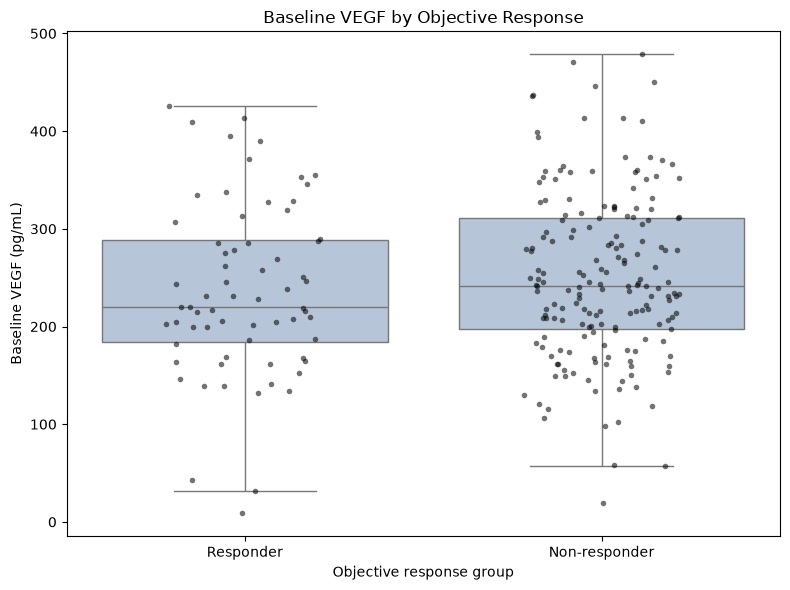

In [32]:
# Set the response-group display order
response_order = ["Responder", "Non-responder"]

# Create the figure
plt.figure(figsize=(8, 6))

# Display the VEGF distribution, median, and interquartile range
sns.boxplot(
    data=response_analysis,
    x="response_group",
    y="vegf_pg_ml",
    order=response_order,
    showfliers=False,
    color="lightsteelblue"
)

# Overlay individual patient VEGF measurements
sns.stripplot(
    data=response_analysis,
    x="response_group",
    y="vegf_pg_ml",
    order=response_order,
    color="black",
    alpha=0.55,
    jitter=0.22,
    size=4
)

# Add clear labels and a descriptive title
plt.xlabel("Objective response group")
plt.ylabel("Baseline VEGF (pg/mL)")
plt.title("Baseline VEGF by Objective Response")

# Improve spacing and display the figure
plt.tight_layout()
plt.show()

#### Descriptive statistics for baseline VEGF

**Objective:** Quantify the center and spread of baseline VEGF within each
response group before conducting statistical inference.

The median and interquartile range will describe the typical distributions,
while the mean and standard deviation will provide additional information
about asymmetry and extreme observations.

In [33]:
# Calculate descriptive statistics for VEGF within each response group
vegf_summary = (
    response_analysis
    .groupby("response_group")["vegf_pg_ml"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
)

# Calculate the interquartile range
vegf_summary["iqr"] = vegf_summary["q3"] - vegf_summary["q1"]

# Arrange the response groups and round values for interpretation
vegf_summary = vegf_summary.loc[
    ["Responder", "Non-responder"]
].round(2)

vegf_summary

,n,mean,median,std,q1,q3,iqr
response_group,,,,,,,
Responder,67,237.09,220.0,88.81,184.55,288.35,103.8
Non-responder,179,251.22,241.8,84.54,197.15,311.35,114.2


#### Mann–Whitney U test for baseline VEGF

**Objective:** Evaluate whether baseline VEGF values generally tend to be
higher in one objective-response group than in the other.

The Mann–Whitney U test compares the relative ranks of the two distributions.
It does not measure prediction accuracy, establish causation, or directly
test the numerical difference between group medians.

In [34]:
# Extract non-missing VEGF measurements for each response group
vegf_responders = response_analysis.loc[
    response_analysis["response_group"] == "Responder",
    "vegf_pg_ml"
].dropna()

vegf_nonresponders = response_analysis.loc[
    response_analysis["response_group"] == "Non-responder",
    "vegf_pg_ml"
].dropna()

# Perform a two-sided Mann–Whitney U test
# Responders are entered first to preserve the effect-size direction
vegf_u_statistic, vegf_p_value = mannwhitneyu(
    vegf_responders,
    vegf_nonresponders,
    alternative="two-sided"
)

# Display sample sizes and test results
print(f"Responders: n = {len(vegf_responders)}")
print(f"Non-responders: n = {len(vegf_nonresponders)}")
print(f"Mann–Whitney U statistic: {vegf_u_statistic:.1f}")
print(f"Two-sided raw p-value: {vegf_p_value:.4f}")

Responders: n = 67
Non-responders: n = 179
Mann–Whitney U statistic: 5452.0
Two-sided raw p-value: 0.2736


#### Probability of superiority and rank-biserial correlation

**Objective:** Quantify the direction and magnitude of baseline VEGF
separation between responders and non-responders.

Probability of superiority estimates how often a randomly selected responder
has a higher VEGF value than a randomly selected non-responder.
Rank-biserial correlation expresses the same comparison from −1 to +1.
Negative values indicate a tendency toward higher VEGF among non-responders.

In [35]:
# Calculate the number of possible responder–non-responder pairs
vegf_total_pairs = len(vegf_responders) * len(vegf_nonresponders)

# Convert the Mann–Whitney U statistic into probability of superiority
# Responders were entered first in the Mann–Whitney test
vegf_probability_superiority = vegf_u_statistic / vegf_total_pairs

# Convert probability of superiority to rank-biserial correlation
# Negative values indicate a tendency toward higher VEGF
# among non-responders
vegf_rank_biserial = (2 * vegf_probability_superiority) - 1

# Display the effect-size results
print(f"Total responder–non-responder pairs: {vegf_total_pairs:,}")
print(
    "Probability that a responder has higher VEGF: "
    f"{vegf_probability_superiority:.3f}"
)
print(f"Rank-biserial correlation: {vegf_rank_biserial:.3f}")

Total responder–non-responder pairs: 11,993
Probability that a responder has higher VEGF: 0.455
Rank-biserial correlation: -0.091


#### Bootstrap confidence interval for the VEGF effect size

**Objective:** Estimate the sampling uncertainty around the rank-biserial
correlation between baseline VEGF and objective response.

Patients will be resampled with replacement within each response group.
The rank-biserial correlation will be recalculated 5,000 times, and the
2.5th and 97.5th percentiles will define the bootstrap 95% confidence
interval.

In [36]:
# Create a reproducible random-number generator
rng = np.random.default_rng(seed=42)

# Store the bootstrapped VEGF effect sizes
vegf_bootstrap_effects = []

# Repeat group-wise resampling 5,000 times
for _ in range(5000):

    # Resample patients within each response group with replacement
    responder_sample = rng.choice(
        vegf_responders,
        size=len(vegf_responders),
        replace=True
    )
    nonresponder_sample = rng.choice(
        vegf_nonresponders,
        size=len(vegf_nonresponders),
        replace=True
    )

    # Recalculate the Mann–Whitney U statistic
    bootstrap_u, _ = mannwhitneyu(
        responder_sample,
        nonresponder_sample,
        alternative="two-sided"
    )

    # Convert U into a rank-biserial correlation
    bootstrap_probability = bootstrap_u / (
        len(responder_sample) * len(nonresponder_sample)
    )
    bootstrap_rank_biserial = (2 * bootstrap_probability) - 1

    # Store this bootstrap estimate
    vegf_bootstrap_effects.append(bootstrap_rank_biserial)

# Calculate the percentile-based 95% confidence interval
vegf_ci_lower, vegf_ci_upper = np.percentile(
    vegf_bootstrap_effects,
    [2.5, 97.5]
)

# Display the observed effect size and confidence interval
print(f"Rank-biserial correlation: {vegf_rank_biserial:.3f}")
print(
    f"Bootstrap 95% CI: {vegf_ci_lower:.3f} to "
    f"{vegf_ci_upper:.3f}"
)

Rank-biserial correlation: -0.091
Bootstrap 95% CI: -0.254 to 0.069


### VEGF interpretation

Baseline VEGF showed a small degree of separation between objective responders
and non-responders. Responders had a median VEGF concentration of
220.0 pg/mL, compared with 241.8 pg/mL among non-responders, corresponding
to an observed median difference of −21.8 pg/mL. The direction was consistent
with the hypothesis that higher angiogenic activity or disease burden may be
associated with non-response. However, the distributions showed substantial
overlap.

The probability that a randomly selected responder had higher baseline VEGF
than a randomly selected non-responder was 45.5%
(rank-biserial correlation = −0.091; bootstrap 95% CI: −0.254 to 0.069).
The confidence interval included zero and allowed for a small effect in the
opposite direction. The two-sided Mann–Whitney U test did not provide clear
statistical evidence of a distributional difference
(U = 5452.0, raw p = 0.274).

Overall, baseline VEGF showed a small association in the hypothesized
direction, but the magnitude was limited and the uncertainty was substantial.
These results do not provide convincing evidence that baseline VEGF is a
standalone objective-response biomarker in this exploratory dataset.

### Baseline TNF-α and objective response

**Objective:** Evaluate whether baseline TNF-α differs between objective
responders (CR/PR) and non-responders (SD/PD).

**Biological hypothesis:** Higher baseline TNF-α may reflect chronic
inflammation, aggressive disease, or an immunosuppressive tumor environment
and may therefore be associated with non-response.

TNF-α has context-dependent biological effects. It can contribute to immune
activation and tumor-cell death, but chronic TNF-α signaling may also support
tumor progression and treatment resistance. Circulating TNF-α does not
directly measure TNF-α activity within the tumor microenvironment.

The analysis will first examine patient-level distributions before
quantifying the effect size, uncertainty, and statistical evidence.

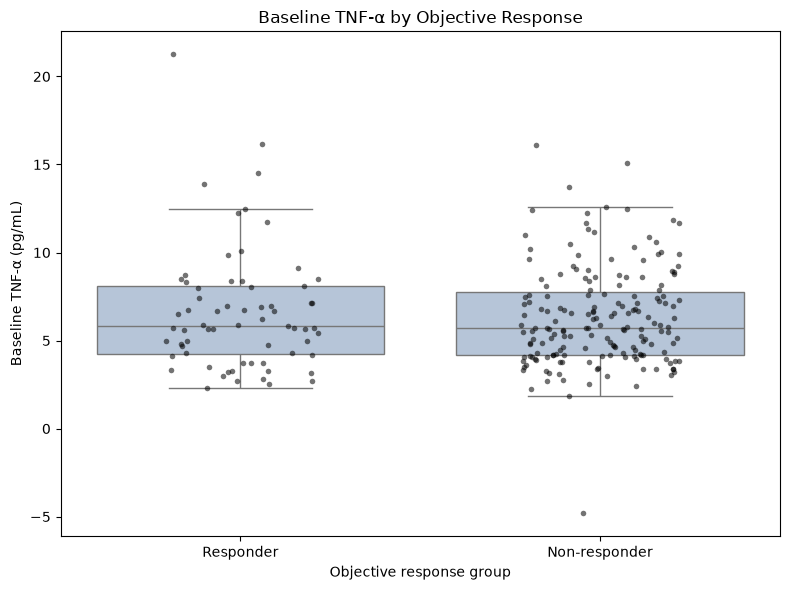

In [37]:
# Set the response-group display order
response_order = ["Responder", "Non-responder"]

# Create the figure
plt.figure(figsize=(8, 6))

# Display the TNF-α distribution, median, and interquartile range
sns.boxplot(
    data=response_analysis,
    x="response_group",
    y="tnf_alpha_pg_ml",
    order=response_order,
    showfliers=False,
    color="lightsteelblue"
)

# Overlay individual patient TNF-α measurements
sns.stripplot(
    data=response_analysis,
    x="response_group",
    y="tnf_alpha_pg_ml",
    order=response_order,
    color="black",
    alpha=0.55,
    jitter=0.22,
    size=4
)

# Add clear labels and a descriptive title
plt.xlabel("Objective response group")
plt.ylabel("Baseline TNF-α (pg/mL)")
plt.title("Baseline TNF-α by Objective Response")

# Improve spacing and display the figure
plt.tight_layout()
plt.show()

#### Descriptive statistics for baseline TNF-α

**Objective:** Quantify the center and spread of baseline TNF-α within each
response group before conducting statistical inference.

The median and interquartile range will describe the typical distributions,
while the mean and standard deviation will provide additional information
about asymmetry and extreme observations.

In [38]:
# Calculate descriptive statistics for TNF-α within each response group
tnf_summary = (
    response_analysis
    .groupby("response_group")["tnf_alpha_pg_ml"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
)

# Calculate the interquartile range
tnf_summary["iqr"] = tnf_summary["q3"] - tnf_summary["q1"]

# Arrange the response groups and round values for interpretation
tnf_summary = tnf_summary.loc[
    ["Responder", "Non-responder"]
].round(2)

tnf_summary

,n,mean,median,std,q1,q3,iqr
response_group,,,,,,,
Responder,67,6.63,5.80,3.5,4.23,8.09,3.86
Non-responder,179,6.32,5.73,2.8,4.20,7.74,3.54


#### Mann–Whitney U test for baseline TNF-α

**Objective:** Evaluate whether baseline TNF-α values generally tend to be
higher in one objective-response group than in the other.

The Mann–Whitney U test compares the relative ranks of the two distributions.
It does not establish that the distributions are identical when statistical
evidence is weak, measure prediction accuracy, or demonstrate causation.

In [39]:
# Extract non-missing TNF-α measurements for each response group
tnf_responders = response_analysis.loc[
    response_analysis["response_group"] == "Responder",
    "tnf_alpha_pg_ml"
].dropna()

tnf_nonresponders = response_analysis.loc[
    response_analysis["response_group"] == "Non-responder",
    "tnf_alpha_pg_ml"
].dropna()

# Perform a two-sided Mann–Whitney U test
# Responders are entered first to preserve the effect-size direction
tnf_u_statistic, tnf_p_value = mannwhitneyu(
    tnf_responders,
    tnf_nonresponders,
    alternative="two-sided"
)

# Display the sample sizes and test results
print(f"Responders: n = {len(tnf_responders)}")
print(f"Non-responders: n = {len(tnf_nonresponders)}")
print(f"Mann–Whitney U statistic: {tnf_u_statistic:.1f}")
print(f"Two-sided raw p-value: {tnf_p_value:.4f}")

Responders: n = 67
Non-responders: n = 179
Mann–Whitney U statistic: 6017.0
Two-sided raw p-value: 0.9679


#### Probability of superiority and rank-biserial correlation

**Objective:** Quantify the direction and magnitude of baseline TNF-α
separation between responders and non-responders.

Probability of superiority estimates how often a randomly selected responder
has a higher TNF-α value than a randomly selected non-responder.
Rank-biserial correlation expresses the same comparison from −1 to +1.
Positive values indicate higher TNF-α ranks among responders, while negative
values indicate higher ranks among non-responders.

In [40]:
# Calculate the number of possible responder–non-responder pairs
tnf_total_pairs = len(tnf_responders) * len(tnf_nonresponders)

# Convert the Mann–Whitney U statistic into probability of superiority
# Responders were entered first in the Mann–Whitney test
tnf_probability_superiority = tnf_u_statistic / tnf_total_pairs

# Convert probability of superiority to rank-biserial correlation
# Positive values indicate a tendency toward higher TNF-α among responders
tnf_rank_biserial = (2 * tnf_probability_superiority) - 1

# Display the effect-size results
print(f"Total responder–non-responder pairs: {tnf_total_pairs:,}")
print(
    "Probability that a responder has higher TNF-α: "
    f"{tnf_probability_superiority:.3f}"
)
print(f"Rank-biserial correlation: {tnf_rank_biserial:.3f}")

Total responder–non-responder pairs: 11,993
Probability that a responder has higher TNF-α: 0.502
Rank-biserial correlation: 0.003


#### Bootstrap confidence interval for the TNF-α effect size

**Objective:** Estimate the sampling uncertainty around the rank-biserial
correlation between baseline TNF-α and objective response.

Patients will be resampled with replacement within each response group.
The rank-biserial correlation will be recalculated 5,000 times, and the
2.5th and 97.5th percentiles will define the bootstrap 95% confidence
interval.

In [41]:
# Create a reproducible random-number generator
rng = np.random.default_rng(seed=42)

# Store the bootstrapped TNF-α effect sizes
tnf_bootstrap_effects = []

# Repeat group-wise resampling 5,000 times
for _ in range(5000):

    # Resample patients within each response group with replacement
    responder_sample = rng.choice(
        tnf_responders,
        size=len(tnf_responders),
        replace=True
    )
    nonresponder_sample = rng.choice(
        tnf_nonresponders,
        size=len(tnf_nonresponders),
        replace=True
    )

    # Recalculate the Mann–Whitney U statistic
    bootstrap_u, _ = mannwhitneyu(
        responder_sample,
        nonresponder_sample,
        alternative="two-sided"
    )

    # Convert U into a rank-biserial correlation
    bootstrap_probability = bootstrap_u / (
        len(responder_sample) * len(nonresponder_sample)
    )
    bootstrap_rank_biserial = (2 * bootstrap_probability) - 1

    # Store this bootstrap estimate
    tnf_bootstrap_effects.append(bootstrap_rank_biserial)

# Calculate the percentile-based 95% confidence interval
tnf_ci_lower, tnf_ci_upper = np.percentile(
    tnf_bootstrap_effects,
    [2.5, 97.5]
)

# Display the observed effect size and confidence interval
print(f"Rank-biserial correlation: {tnf_rank_biserial:.3f}")
print(
    f"Bootstrap 95% CI: {tnf_ci_lower:.3f} to "
    f"{tnf_ci_upper:.3f}"
)

Rank-biserial correlation: 0.003
Bootstrap 95% CI: -0.161 to 0.172


### TNF-α interpretation

Baseline TNF-α showed essentially no separation between objective responders
and non-responders. Responders had a median TNF-α concentration of
5.80 pg/mL, compared with 5.73 pg/mL among non-responders, corresponding
to an observed median difference of 0.07 pg/mL. This difference was
negligible relative to the within-group variability and substantial
distributional overlap.

The probability that a randomly selected responder had higher baseline TNF-α
than a randomly selected non-responder was 50.2%
(rank-biserial correlation = 0.003; bootstrap 95% CI: −0.161 to 0.172).
The confidence interval included zero and allowed for effects in either
direction. The two-sided Mann–Whitney U test provided no clear statistical
evidence of a distributional difference
(U = 6017.0, raw p = 0.968).

Overall, baseline circulating TNF-α demonstrated limited potential as a
standalone objective-response biomarker in this pooled exploratory analysis.
This finding does not establish that TNF-α biology is unimportant. A single
circulating baseline measurement may not represent TNF-α signaling within
the tumor microenvironment, and an association could depend on treatment,
other inflammatory pathways, or longitudinal changes.

### Baseline CRP and objective response

**Objective:** Evaluate whether baseline CRP differs between objective
responders (CR/PR) and non-responders (SD/PD).

**Biological hypothesis:** Higher baseline CRP may reflect greater systemic
inflammation, tumor burden, tissue injury, or aggressive disease and may
therefore be associated with non-response.

CRP is produced mainly by the liver in response to inflammatory signaling,
particularly IL-6. Because baseline IL-6 and CRP were strongly correlated in
Notebook 03, these biomarkers may provide partly overlapping biological
information. CRP is also influenced by infection, comorbid inflammatory
conditions, liver function, and medications and is not tumor-specific.

The analysis will first examine patient-level distributions before
quantifying the effect size, uncertainty, and statistical evidence.

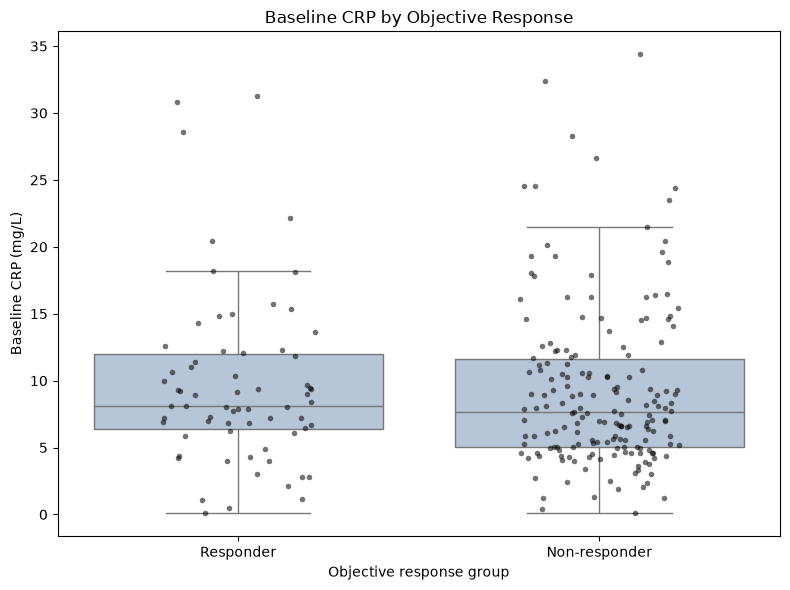

In [42]:
# Set the response-group display order
response_order = ["Responder", "Non-responder"]

# Create the figure
plt.figure(figsize=(8, 6))

# Display the CRP distribution, median, and interquartile range
sns.boxplot(
    data=response_analysis,
    x="response_group",
    y="crp_mg_l",
    order=response_order,
    showfliers=False,
    color="lightsteelblue"
)

# Overlay individual patient CRP measurements
sns.stripplot(
    data=response_analysis,
    x="response_group",
    y="crp_mg_l",
    order=response_order,
    color="black",
    alpha=0.55,
    jitter=0.22,
    size=4
)

# Add clear labels and a descriptive title
plt.xlabel("Objective response group")
plt.ylabel("Baseline CRP (mg/L)")
plt.title("Baseline CRP by Objective Response")

# Improve spacing and display the figure
plt.tight_layout()
plt.show()

#### Descriptive statistics for baseline CRP

**Objective:** Quantify the center and spread of baseline CRP within each
response group before conducting statistical inference.

The median and interquartile range will describe the typical distributions,
while the mean and standard deviation will provide additional information
about asymmetry and extreme observations.

In [43]:
# Calculate descriptive statistics for CRP within each response group
crp_summary = (
    response_analysis
    .groupby("response_group")["crp_mg_l"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
)

# Calculate the interquartile range
crp_summary["iqr"] = crp_summary["q3"] - crp_summary["q1"]

# Arrange the response groups and round values for interpretation
crp_summary = crp_summary.loc[
    ["Responder", "Non-responder"]
].round(2)

crp_summary

,n,mean,median,std,q1,q3,iqr
response_group,,,,,,,
Responder,67,9.67,8.14,6.41,6.35,11.98,5.62
Non-responder,178,9.22,7.65,6.00,5.04,11.62,6.57


#### Mann–Whitney U test for baseline CRP

**Objective:** Evaluate whether baseline CRP values generally tend to be
higher in one objective-response group than in the other.

The Mann–Whitney U test compares the relative ranks of the two distributions.
One non-responder with missing CRP will be excluded from this biomarker-specific
analysis without replacing the missing value.

In [44]:
# Extract non-missing CRP measurements for each response group
crp_responders = response_analysis.loc[
    response_analysis["response_group"] == "Responder",
    "crp_mg_l"
].dropna()

crp_nonresponders = response_analysis.loc[
    response_analysis["response_group"] == "Non-responder",
    "crp_mg_l"
].dropna()

# Perform a two-sided Mann–Whitney U test
# Responders are entered first to preserve the effect-size direction
crp_u_statistic, crp_p_value = mannwhitneyu(
    crp_responders,
    crp_nonresponders,
    alternative="two-sided"
)

# Display the biomarker-specific sample sizes and test results
print(f"Responders: n = {len(crp_responders)}")
print(f"Non-responders: n = {len(crp_nonresponders)}")
print(f"Mann–Whitney U statistic: {crp_u_statistic:.1f}")
print(f"Two-sided raw p-value: {crp_p_value:.4f}")

Responders: n = 67
Non-responders: n = 178
Mann–Whitney U statistic: 6369.0
Two-sided raw p-value: 0.4122


#### Probability of superiority and rank-biserial correlation

**Objective:** Quantify the direction and magnitude of baseline CRP
separation between responders and non-responders.

Probability of superiority estimates how often a randomly selected responder
has a higher CRP value than a randomly selected non-responder.
Rank-biserial correlation expresses the same comparison from −1 to +1.
Positive values indicate higher CRP ranks among responders, while negative
values indicate higher ranks among non-responders.

In [45]:
# Calculate the number of possible responder–non-responder pairs
# CRP has one missing value among non-responders
crp_total_pairs = len(crp_responders) * len(crp_nonresponders)

# Convert the Mann–Whitney U statistic into probability of superiority
# Responders were entered first in the test
crp_probability_superiority = crp_u_statistic / crp_total_pairs

# Convert probability of superiority to rank-biserial correlation
# Positive values indicate a tendency toward higher CRP among responders
crp_rank_biserial = (2 * crp_probability_superiority) - 1

# Display the effect-size results
print(f"Total responder–non-responder pairs: {crp_total_pairs:,}")
print(
    "Probability that a responder has higher CRP: "
    f"{crp_probability_superiority:.3f}"
)
print(f"Rank-biserial correlation: {crp_rank_biserial:.3f}")

Total responder–non-responder pairs: 11,926
Probability that a responder has higher CRP: 0.534
Rank-biserial correlation: 0.068


#### Bootstrap confidence interval for the CRP effect size

**Objective:** Estimate the sampling uncertainty around the rank-biserial
correlation between baseline CRP and objective response.

Patients will be resampled with replacement within each response group.
The rank-biserial correlation will be recalculated 5,000 times, and the
2.5th and 97.5th percentiles will define the bootstrap 95% confidence
interval.

In [46]:
# Create a reproducible random-number generator
rng = np.random.default_rng(seed=42)

# Store the bootstrapped CRP effect sizes
crp_bootstrap_effects = []

# Repeat group-wise resampling 5,000 times
for _ in range(5000):

    # Resample patients within each response group with replacement
    responder_sample = rng.choice(
        crp_responders,
        size=len(crp_responders),
        replace=True
    )
    nonresponder_sample = rng.choice(
        crp_nonresponders,
        size=len(crp_nonresponders),
        replace=True
    )

    # Recalculate the Mann–Whitney U statistic
    bootstrap_u, _ = mannwhitneyu(
        responder_sample,
        nonresponder_sample,
        alternative="two-sided"
    )

    # Convert U into a rank-biserial correlation
    bootstrap_probability = bootstrap_u / (
        len(responder_sample) * len(nonresponder_sample)
    )
    bootstrap_rank_biserial = (2 * bootstrap_probability) - 1

    # Store this bootstrap estimate
    crp_bootstrap_effects.append(bootstrap_rank_biserial)

# Calculate the percentile-based 95% confidence interval
crp_ci_lower, crp_ci_upper = np.percentile(
    crp_bootstrap_effects,
    [2.5, 97.5]
)

# Display the observed effect size and confidence interval
print(f"Rank-biserial correlation: {crp_rank_biserial:.3f}")
print(
    f"Bootstrap 95% CI: {crp_ci_lower:.3f} to "
    f"{crp_ci_upper:.3f}"
)

Rank-biserial correlation: 0.068
Bootstrap 95% CI: -0.098 to 0.226


### CRP interpretation

Baseline CRP showed minimal separation between objective responders and
non-responders. Responders had a median CRP concentration of 8.14 mg/L,
compared with 7.65 mg/L among non-responders, corresponding to an observed
median difference of 0.49 mg/L. This difference was small relative to the
within-group variability and substantial distributional overlap.

The probability that a randomly selected responder had higher baseline CRP
than a randomly selected non-responder was 53.4%
(rank-biserial correlation = 0.068; bootstrap 95% CI: −0.098 to 0.226).
The confidence interval included zero and allowed for effects in either
direction. The two-sided Mann–Whitney U test provided no clear statistical
evidence of a distributional difference
(U = 6369.0, raw p = 0.412).

The observed direction was opposite the initial hypothesis: responders
tended to have slightly higher CRP. However, the effect was small and
uncertain and should not be interpreted as evidence that higher CRP promotes
response.

Overall, baseline CRP demonstrated limited potential as a standalone
objective-response biomarker in this pooled exploratory analysis. Although
CRP was strongly correlated with IL-6 in the baseline correlation analysis,
that relationship did not imply that either marker would distinguish
response groups.

## Comparison of baseline biomarker associations with objective response

**Objective:** Assemble the results from all seven univariate biomarker
analyses into one numeric table before applying multiple-testing correction.

For each biomarker, the table includes biomarker-specific sample sizes,
the responder-minus-non-responder median difference, rank-biserial
correlation, bootstrap 95% confidence interval, Mann–Whitney U statistic,
and raw p-value.

Positive rank-biserial correlations indicate a tendency toward higher values
among responders. Negative values indicate a tendency toward higher values
among non-responders.

In [47]:
# Preserve the previously calculated IL-6 Mann–Whitney results
# under biomarker-specific variable names
il6_u_statistic = u_statistic
il6_p_value = p_value

# Calculate the IL-6 probability of superiority
il6_total_pairs = len(il6_responders) * len(il6_nonresponders)
il6_probability_superiority = il6_u_statistic / il6_total_pairs

# Convert the probability into a rank-biserial correlation
il6_rank_biserial = (2 * il6_probability_superiority) - 1

# Recalculate the IL-6 bootstrap confidence interval using clear variable names
rng = np.random.default_rng(seed=42)
il6_bootstrap_effects = []

for _ in range(5000):

    # Resample patients within each response group
    responder_sample = rng.choice(
        il6_responders,
        size=len(il6_responders),
        replace=True
    )
    nonresponder_sample = rng.choice(
        il6_nonresponders,
        size=len(il6_nonresponders),
        replace=True
    )

    # Calculate the Mann–Whitney statistic in the bootstrap sample
    bootstrap_u, _ = mannwhitneyu(
        responder_sample,
        nonresponder_sample,
        alternative="two-sided"
    )

    # Convert the bootstrap statistic into the effect size
    bootstrap_probability = bootstrap_u / (
        len(responder_sample) * len(nonresponder_sample)
    )
    il6_bootstrap_effects.append(
        (2 * bootstrap_probability) - 1
    )

# Calculate the percentile-based 95% confidence interval
il6_ci_lower, il6_ci_upper = np.percentile(
    il6_bootstrap_effects,
    [2.5, 97.5]
)

# Confirm that the named IL-6 results match the earlier analysis
print(f"IL-6 U statistic: {il6_u_statistic:.1f}")
print(f"IL-6 rank-biserial correlation: {il6_rank_biserial:.3f}")
print(f"IL-6 bootstrap 95% CI: {il6_ci_lower:.3f} to {il6_ci_upper:.3f}")
print(f"IL-6 raw p-value: {il6_p_value:.4f}")

IL-6 U statistic: 6329.0
IL-6 rank-biserial correlation: 0.061
IL-6 bootstrap 95% CI: -0.098 to 0.224
IL-6 raw p-value: 0.4598


In [48]:
# Assemble the numeric results from the seven univariate analyses
# All values remain numeric so they can be used in later calculations
biomarker_response_results = pd.DataFrame({
    "biomarker": [
        "IL-6",
        "CRP",
        "TNF-alpha",
        "IFN-gamma",
        "VEGF",
        "PD-L1 TPS",
        "ctDNA fraction"
    ],
    "n_responder": [
        len(il6_responders),
        len(crp_responders),
        len(tnf_responders),
        len(ifng_responders),
        len(vegf_responders),
        len(pdl1_responders),
        len(ctdna_responders)
    ],
    "n_nonresponder": [
        len(il6_nonresponders),
        len(crp_nonresponders),
        len(tnf_nonresponders),
        len(ifng_nonresponders),
        len(vegf_nonresponders),
        len(pdl1_nonresponders),
        len(ctdna_nonresponders)
    ],
    "median_difference": [
        0.33,
        0.49,
        0.07,
        -0.30,
        -21.80,
        -3.40,
        0.41
    ],
    "rank_biserial": [
        il6_rank_biserial,
        crp_rank_biserial,
        tnf_rank_biserial,
        ifng_rank_biserial,
        vegf_rank_biserial,
        pdl1_rank_biserial,
        ctdna_rank_biserial
    ],
    "ci_lower": [
        il6_ci_lower,
        crp_ci_lower,
        tnf_ci_lower,
        ifng_ci_lower,
        vegf_ci_lower,
        pdl1_ci_lower,
        ctdna_ci_lower
    ],
    "ci_upper": [
        il6_ci_upper,
        crp_ci_upper,
        tnf_ci_upper,
        ifng_ci_upper,
        vegf_ci_upper,
        pdl1_ci_upper,
        ctdna_ci_upper
    ],
    "mann_whitney_u": [
        il6_u_statistic,
        crp_u_statistic,
        tnf_u_statistic,
        ifng_u_statistic,
        vegf_u_statistic,
        pdl1_u_statistic,
        ctdna_u_statistic
    ],
    "raw_p_value": [
        il6_p_value,
        crp_p_value,
        tnf_p_value,
        ifng_p_value,
        vegf_p_value,
        pdl1_p_value,
        ctdna_p_value
    ]
})

# Display a rounded copy for easier inspection
# The underlying DataFrame retains its full numeric precision
biomarker_response_results.round(3)

,biomarker,n_responder,n_nonresponder,median_difference,rank_biserial,ci_lower,ci_upper,mann_whitney_u,raw_p_value
0,IL-6,67,178,0.33,0.061,-0.098,0.224,6329.0,0.460
1,CRP,67,178,0.49,0.068,-0.098,0.226,6369.0,0.412
2,TNF-alpha,67,179,0.07,0.003,-0.161,0.172,6017.0,0.968
3,IFN-gamma,67,179,-0.30,-0.011,-0.181,0.161,5928.0,0.891
4,VEGF,67,179,-21.80,-0.091,-0.254,0.069,5452.0,0.274
5,PD-L1 TPS,67,179,-3.40,-0.070,-0.230,0.085,5578.0,0.400
6,ctDNA fraction,67,179,0.41,0.030,-0.133,0.191,6173.5,0.722


### Multiple-testing correction across baseline biomarkers

**Objective:** Control the expected proportion of false discoveries across
the seven univariate biomarker–response tests using the Benjamini–Hochberg
False Discovery Rate procedure.

Each raw p-value evaluates one biomarker separately. Testing multiple
biomarkers increases the opportunity to obtain a small p-value by chance.
The FDR adjustment accounts for this multiplicity while generally being less
conservative than procedures designed to prevent any false positive.

FDR correction changes the statistical-evidence assessment. It does not
change the observed effect sizes, confidence intervals, biological meaning,
or predictive performance of the biomarkers.

In [49]:
# Import the Benjamini–Hochberg multiple-testing procedure
from statsmodels.stats.multitest import multipletests

# Apply Benjamini–Hochberg FDR correction across all seven raw p-values
reject_fdr, fdr_p_values, _, _ = multipletests(
    biomarker_response_results["raw_p_value"],
    alpha=0.05,
    method="fdr_bh"
)

# Add the adjusted p-values and FDR decision to the numeric table
biomarker_response_results["fdr_p_value"] = fdr_p_values
biomarker_response_results["significant_fdr_0_05"] = reject_fdr

# Sort by raw p-value so the strongest statistical evidence appears first
biomarker_response_results = (
    biomarker_response_results
    .sort_values("raw_p_value")
    .reset_index(drop=True)
)

# Display a rounded copy while retaining full precision in the underlying table
biomarker_response_results.round(3)

,biomarker,n_responder,n_nonresponder,median_difference,rank_biserial,ci_lower,ci_upper,mann_whitney_u,raw_p_value,fdr_p_value,significant_fdr_0_05
0,VEGF,67,179,-21.80,-0.091,-0.254,0.069,5452.0,0.274,0.805,False
1,PD-L1 TPS,67,179,-3.40,-0.070,-0.230,0.085,5578.0,0.400,0.805,False
2,CRP,67,178,0.49,0.068,-0.098,0.226,6369.0,0.412,0.805,False
3,IL-6,67,178,0.33,0.061,-0.098,0.224,6329.0,0.460,0.805,False
4,ctDNA fraction,67,179,0.41,0.030,-0.133,0.191,6173.5,0.722,0.968,False
5,IFN-gamma,67,179,-0.30,-0.011,-0.181,0.161,5928.0,0.891,0.968,False
6,TNF-alpha,67,179,0.07,0.003,-0.161,0.172,6017.0,0.968,0.968,False


### Overall univariate biomarker interpretation

Across seven pooled univariate comparisons, none of the evaluated baseline
biomarkers showed clear evidence of an association with objective response
after Benjamini–Hochberg FDR correction.

All observed rank-biserial correlations were small in magnitude, ranging
from −0.091 for VEGF to 0.068 for CRP, and every bootstrap 95% confidence
interval included zero. VEGF showed the largest observed separation and was
directionally consistent with the hypothesis that higher angiogenic activity
may be associated with non-response. However, its effect was small
(rank-biserial correlation = −0.091; bootstrap 95% CI: −0.254 to 0.069),
and the statistical evidence was inconclusive
(raw p = 0.274; FDR-adjusted p = 0.805).

Overall, IL-6, CRP, TNF-α, IFN-γ, VEGF, PD-L1 TPS, and ctDNA fraction
demonstrated limited potential as standalone baseline objective-response
biomarkers in this pooled exploratory analysis. These findings do not
establish that the underlying biological pathways are unimportant and do
not exclude associations involving biomarker combinations, clinical
covariates, longitudinal changes, or treatment-specific effects.

### Save biomarker–response results

**Objective:** Save the seven univariate biomarker results in both numeric
and human-readable formats.

The full-precision numeric table will be used for calculations and future
analyses. The formatted table will be used only for reporting because its
confidence intervals and statistical decisions are stored as text.

In [50]:
# Save the full-precision numeric results table
# This version should be used for future calculations
numeric_output_path = "../results/biomarker_response_univariate_results.csv"

biomarker_response_results.to_csv(
    numeric_output_path,
    index=False
)

print(f"Numeric results saved to: {numeric_output_path}")

Numeric results saved to: ../results/biomarker_response_univariate_results.csv


In [51]:
# Create a separate copy for human-readable reporting
biomarker_response_formatted = biomarker_response_results.copy()

# Combine the lower and upper confidence limits into one reporting column
biomarker_response_formatted["bootstrap_95_ci"] = (
    biomarker_response_formatted["ci_lower"].map(lambda x: f"{x:.3f}")
    + " to "
    + biomarker_response_formatted["ci_upper"].map(lambda x: f"{x:.3f}")
)

# Format numerical results for readability
# These become text and should not be used for later calculations
biomarker_response_formatted["median_difference"] = (
    biomarker_response_formatted["median_difference"].map(lambda x: f"{x:.2f}")
)
biomarker_response_formatted["rank_biserial"] = (
    biomarker_response_formatted["rank_biserial"].map(lambda x: f"{x:.3f}")
)
biomarker_response_formatted["mann_whitney_u"] = (
    biomarker_response_formatted["mann_whitney_u"].map(lambda x: f"{x:.1f}")
)
biomarker_response_formatted["raw_p_value"] = (
    biomarker_response_formatted["raw_p_value"].map(lambda x: f"{x:.3f}")
)
biomarker_response_formatted["fdr_p_value"] = (
    biomarker_response_formatted["fdr_p_value"].map(lambda x: f"{x:.3f}")
)

# Replace the Boolean decision with a reader-friendly label
biomarker_response_formatted["significant_after_fdr"] = (
    biomarker_response_formatted["significant_fdr_0_05"]
    .map({True: "Yes", False: "No"})
)

# Select and arrange the reporting columns
biomarker_response_formatted = biomarker_response_formatted[
    [
        "biomarker",
        "n_responder",
        "n_nonresponder",
        "median_difference",
        "rank_biserial",
        "bootstrap_95_ci",
        "raw_p_value",
        "fdr_p_value",
        "significant_after_fdr"
    ]
]

# Display the formatted reporting table
biomarker_response_formatted

,biomarker,n_responder,n_nonresponder,median_difference,rank_biserial,bootstrap_95_ci,raw_p_value,fdr_p_value,significant_after_fdr
0,VEGF,67,179,-21.80,-0.091,-0.254 to 0.069,0.274,0.805,No
1,PD-L1 TPS,67,179,-3.40,-0.070,-0.230 to 0.085,0.400,0.805,No
2,CRP,67,178,0.49,0.068,-0.098 to 0.226,0.412,0.805,No
3,IL-6,67,178,0.33,0.061,-0.098 to 0.224,0.460,0.805,No
4,ctDNA fraction,67,179,0.41,0.030,-0.133 to 0.191,0.722,0.968,No
5,IFN-gamma,67,179,-0.30,-0.011,-0.181 to 0.161,0.891,0.968,No
6,TNF-alpha,67,179,0.07,0.003,-0.161 to 0.172,0.968,0.968,No


In [52]:
# Save the human-readable reporting table
# This version should not be used for numerical calculations
formatted_output_path = (
    "../results/biomarker_response_univariate_results_formatted.csv"
)

biomarker_response_formatted.to_csv(
    formatted_output_path,
    index=False
)

print(f"Formatted results saved to: {formatted_output_path}")

Formatted results saved to: ../results/biomarker_response_univariate_results_formatted.csv


In [53]:
# Define the two saved result paths
numeric_output_path = "../results/biomarker_response_univariate_results.csv"
formatted_output_path = (
    "../results/biomarker_response_univariate_results_formatted.csv"
)

# Confirm that both result files exist
print("Numeric file exists:", Path(numeric_output_path).exists())
print("Formatted file exists:", Path(formatted_output_path).exists())

# Read the saved files back into Python
numeric_check = pd.read_csv(numeric_output_path)
formatted_check = pd.read_csv(formatted_output_path)

# Confirm their dimensions
print("Numeric table shape:", numeric_check.shape)
print("Formatted table shape:", formatted_check.shape)

# Display the formatted reporting table
formatted_check

Numeric file exists: True
Formatted file exists: True
Numeric table shape: (7, 11)
Formatted table shape: (7, 9)


,biomarker,n_responder,n_nonresponder,median_difference,rank_biserial,bootstrap_95_ci,raw_p_value,fdr_p_value,significant_after_fdr
0,VEGF,67,179,-21.80,-0.091,-0.254 to 0.069,0.274,0.805,No
1,PD-L1 TPS,67,179,-3.40,-0.070,-0.230 to 0.085,0.400,0.805,No
2,CRP,67,178,0.49,0.068,-0.098 to 0.226,0.412,0.805,No
3,IL-6,67,178,0.33,0.061,-0.098 to 0.224,0.460,0.805,No
4,ctDNA fraction,67,179,0.41,0.030,-0.133 to 0.191,0.722,0.968,No
5,IFN-gamma,67,179,-0.30,-0.011,-0.181 to 0.161,0.891,0.968,No
6,TNF-alpha,67,179,0.07,0.003,-0.161 to 0.172,0.968,0.968,No


### Comparative effect-size visualization

**Objective:** Compare the magnitude, direction, and uncertainty of the
associations between all seven baseline biomarkers and objective response.

Rank-biserial correlations are displayed with bootstrap 95% confidence
intervals. Positive values indicate higher biomarker values among responders,
whereas negative values indicate higher values among non-responders. The
vertical line at zero represents no rank-based group separation.

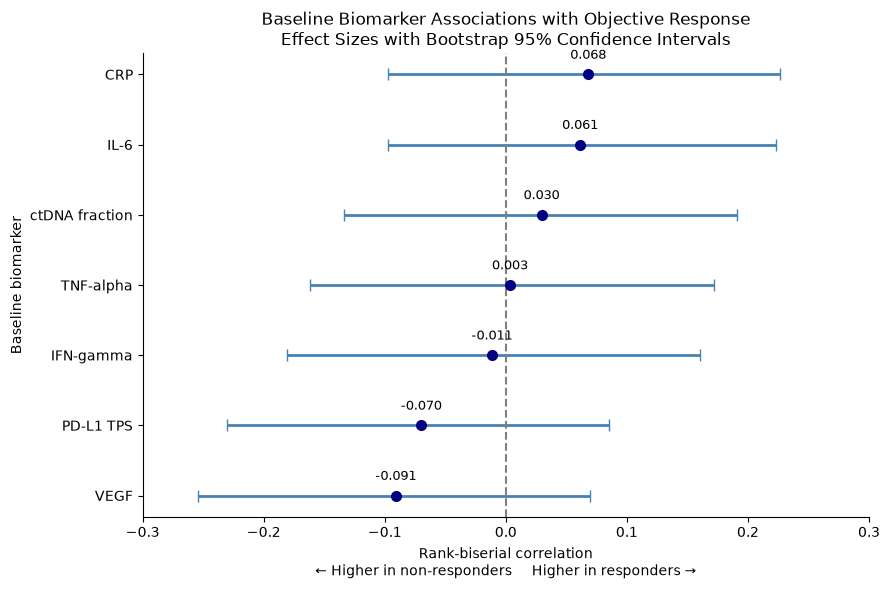

In [54]:
# Sort biomarkers by effect size for an organized visual comparison
forest_data = (
    biomarker_response_results
    .sort_values("rank_biserial")
    .reset_index(drop=True)
)

# Create numeric y-axis positions for the biomarkers
y_positions = np.arange(len(forest_data))

# Calculate asymmetric confidence-interval distances from each point estimate
lower_errors = (
    forest_data["rank_biserial"] - forest_data["ci_lower"]
)
upper_errors = (
    forest_data["ci_upper"] - forest_data["rank_biserial"]
)

# Create the forest plot
fig, ax = plt.subplots(figsize=(9, 6))

# Plot each rank-biserial correlation and its bootstrap 95% confidence interval
ax.errorbar(
    forest_data["rank_biserial"],
    y_positions,
    xerr=[lower_errors, upper_errors],
    fmt="o",
    color="navy",
    ecolor="steelblue",
    elinewidth=2,
    capsize=4,
    markersize=7
)

# Add the reference line representing no group separation
ax.axvline(
    x=0,
    color="gray",
    linestyle="--",
    linewidth=1.5
)

# Label each effect-size estimate with its numerical value
for y, effect in zip(y_positions, forest_data["rank_biserial"]):
    ax.text(
        effect,
        y + 0.18,
        f"{effect:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Add biomarker labels
ax.set_yticks(y_positions)
ax.set_yticklabels(forest_data["biomarker"])

# Use symmetric limits so direction and magnitude are visually comparable
ax.set_xlim(-0.30, 0.30)

# Add clear scientific labels
ax.set_xlabel(
    "Rank-biserial correlation\n"
    "← Higher in non-responders     Higher in responders →"
)
ax.set_ylabel("Baseline biomarker")
ax.set_title(
    "Baseline Biomarker Associations with Objective Response\n"
    "Effect Sizes with Bootstrap 95% Confidence Intervals"
)

# Remove unnecessary plot borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Improve spacing and display without saving yet
plt.tight_layout()
plt.show()

#### Forest-plot interpretation

All seven bootstrap 95% confidence intervals crossed zero, indicating
uncertainty about the direction of each baseline biomarker association with
objective response.

VEGF showed the largest absolute observed effect
(rank-biserial correlation = −0.091), suggesting a small tendency toward
higher baseline VEGF among non-responders. However, its confidence interval
crossed zero, and the magnitude indicated limited patient-level separation.

Overall, the comparative visualization supports the conclusion that none of
the evaluated biomarkers demonstrated convincing standalone separation
between objective responders and non-responders in the pooled analysis.

In [55]:
# save the portfolio-quality forest plot at high resolution
forest_figure_path = (
    "../figures/baseline_biomarker_response_forest_plot.png"
)

fig.savefig(
    forest_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Forest plot saved to: {forest_figure_path}")

Forest plot saved to: ../figures/baseline_biomarker_response_forest_plot.png


In [56]:
# Confirm that the saved figure exists
print("Figure exists:", Path(forest_figure_path).exists())

Figure exists: True


## Conclusions and pharmaceutical interpretation

Among 249 patients with evaluable Best Overall Response, 68 achieved CR or
PR, corresponding to an objective response rate of 27.3%. The biomarker
analysis included 246 patients with both evaluable response and baseline
biomarker data: 67 responders and 179 non-responders.

Across pooled univariate analyses, none of the seven evaluated baseline
biomarkers demonstrated convincing standalone separation between objective
responders and non-responders. All absolute rank-biserial correlations were
small, all bootstrap 95% confidence intervals crossed zero, and no comparison
was statistically significant after Benjamini–Hochberg FDR correction.

VEGF showed the largest observed effect and was directionally consistent with
the hypothesis that greater angiogenic activity or disease burden may be
associated with non-response. However, the effect was small and uncertain
(rank-biserial correlation = −0.091; bootstrap 95% CI: −0.254 to 0.069;
raw p = 0.274; FDR-adjusted p = 0.805).

These findings would not support advancing any evaluated biomarker alone as
a patient-selection assay for objective response. They do not establish that
the underlying pathways are biologically unimportant or exclude potential
value from biomarker combinations, clinical covariate adjustment,
longitudinal measurements, or treatment-specific analyses.

Because treatment arms were pooled, these analyses describe overall
biomarker–response associations. They do not establish whether a biomarker
predicts differential benefit from TRIDENT treatment.